# Lab 3: Linear Regression with Numeric and Nominal Features

Dataset: House Price dataset (500 rows, generated for this lab).

Numeric features: area_sqft, bedrooms, bathrooms, age_years, distance_to_city_km

Nominal features: location, furnishing_status, has_garage

Target: price


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_style("whitegrid")
%matplotlib inline


## 1. Create the dataset

In [32]:
n = 500

area_sqft = np.random.normal(1800, 600, n).clip(400, 5000)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age_years = np.random.randint(0, 40, n)
distance_to_city_km = np.random.exponential(8, n).clip(0.5, 50)

locations = np.random.choice(['Downtown', 'Suburb', 'Rural'], size=n, p=[0.35, 0.45, 0.20])
furnishing = np.random.choice(['Furnished', 'Semi-Furnished', 'Unfurnished'], size=n, p=[0.3, 0.4, 0.3])
has_garage = np.random.choice(['Yes', 'No'], size=n, p=[0.6, 0.4])

location_effect = pd.Series(locations).map({'Downtown': 80, 'Suburb': 30, 'Rural': -20}).values
furnish_effect = pd.Series(furnishing).map({'Furnished': 25, 'Semi-Furnished': 10, 'Unfurnished': -10}).values
garage_effect = pd.Series(has_garage).map({'Yes': 15, 'No': 0}).values

noise = np.random.normal(0, 25, n)

price = (
    50
    + 0.09 * area_sqft
    + 12 * bedrooms
    + 8 * bathrooms
    - 1.2 * age_years
    - 2.5 * distance_to_city_km
    + location_effect
    + furnish_effect
    + garage_effect
    + noise
)

# a couple of irrelevant/random columns, on purpose, to test feature selection later
random_score = np.random.normal(50, 10, n)
lucky_number = np.random.randint(1, 100, n)

df = pd.DataFrame({
    'area_sqft': area_sqft,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age_years,
    'distance_to_city_km': distance_to_city_km,
    'location': locations,
    'furnishing_status': furnishing,
    'has_garage': has_garage,
    'random_score': random_score,
    'lucky_number': lucky_number,
    'price': price
})

# add some missing values
for col, frac in [('area_sqft', 0.03), ('bathrooms', 0.02), ('location', 0.03), ('furnishing_status', 0.02)]:
    missing_idx = df.sample(frac=frac, random_state=1).index
    df.loc[missing_idx, col] = np.nan

df.to_csv('house_price_dataset.csv', index=False)
df.head()


,area_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,location,furnishing_status,has_garage,random_score,lucky_number,price
0,2098.028492,2,2.0,0,8.111261,Downtown,Unfurnished,No,42.106530,51,340.212317
1,1717.041419,2,2.0,4,8.615290,Downtown,Unfurnished,Yes,51.020749,11,315.854677
2,2188.613123,3,1.0,19,18.039335,Downtown,Furnished,Yes,38.864808,63,347.507313
3,2713.817914,3,3.0,7,8.099543,Rural,Unfurnished,Yes,67.701676,57,287.793402
4,1659.507975,5,3.0,11,7.613967,Downtown,Furnished,No,23.591023,12,330.418390


In [33]:
df.isnull().sum()


area_sqft              15
bedrooms                0
bathrooms              10
age_years               0
distance_to_city_km     0
location               15
furnishing_status      10
has_garage              0
random_score            0
lucky_number            0
price                   0
dtype: int64

## 2. Quick look at the data

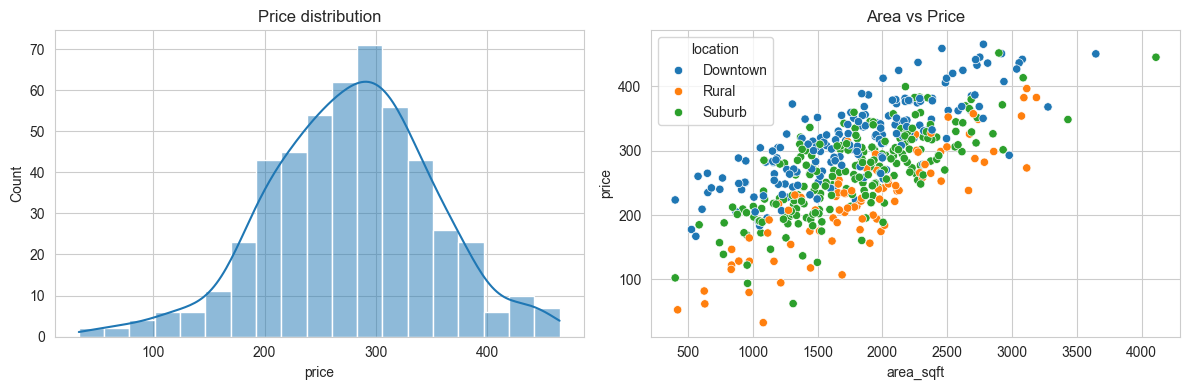

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Price distribution')

sns.scatterplot(data=df, x='area_sqft', y='price', hue='location', ax=axes[1])
axes[1].set_title('Area vs Price')
plt.tight_layout()
plt.show()


## 3. Preprocessing

Missing values: numeric columns filled with median, categorical columns filled with most frequent value.

Categorical variables: encoded with one hot encoding.

Numeric features: scaled with StandardScaler.

All of this is put in a pipeline so it is fit only on the training data.


In [35]:
X = df.drop(columns=['price'])
y = df['price']

numeric_features = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km',
                     'random_score', 'lucky_number']
categorical_features = ['location', 'furnishing_status', 'has_garage']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 4. Train test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 400
Test samples: 100


## 5. Linear Regression model

### Why use a Pipeline and ColumnTransformer?

Instead of manually filling missing values, one-hot encoding categorical variables, and scaling numeric variables for both the training and testing sets separately, we use a Pipeline combined with a ColumnTransformer. 

1. **Prevents Data Leakage:** The pipeline ensures that the statistics used for imputation and scaling (like the mean or median) are learned *only* from the training data, and then applied consistently to the test data.
2. **Simplifies Workflow:** By wrapping the preprocessing steps and the LinearRegression model into a single object, we can train everything in one single .fit() call, and make predictions on new data in a single .predict() call.

In [37]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area_sqft', 'bedrooms',
                                                   'bathrooms', 'age_years',
                                                   'distance_to_city_km',
                                                   'random_score',
                                                   'lucky_number']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['location',
                                                   'furnishing_status',
                                                   'has_garage'])])),
                ('regressor', LinearRegression())])

In [38]:
ohe_cols = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_cols)
coefs = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs}).sort_values('coefficient', key=abs, ascending=False)
coef_df


,feature,coefficient
7,location_Rural,-100.966840
0,area_sqft,52.010562
8,location_Suburb,-49.097660
10,furnishing_status_Unfurnished,-29.253246
4,distance_to_city_km,-19.146823
11,has_garage_Yes,15.657577
1,bedrooms,15.609913
9,furnishing_status_Semi-Furnished,-12.367542
3,age_years,-11.247208
2,bathrooms,4.249782


## 6. Evaluation

In [39]:
def evaluate(model, X, y, label):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    print(label)
    print("MAE:", round(mae, 3))
    print("MSE:", round(mse, 3))
    print("RMSE:", round(rmse, 3))
    print("R2:", round(r2, 4))
    print()
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

train_metrics = evaluate(model, X_train, y_train, "Train")
test_metrics = evaluate(model, X_test, y_test, "Test")


Train
MAE: 20.403
MSE: 666.071
RMSE: 25.808
R2: 0.8798

Test
MAE: 21.459
MSE: 787.13
RMSE: 28.056
R2: 0.832



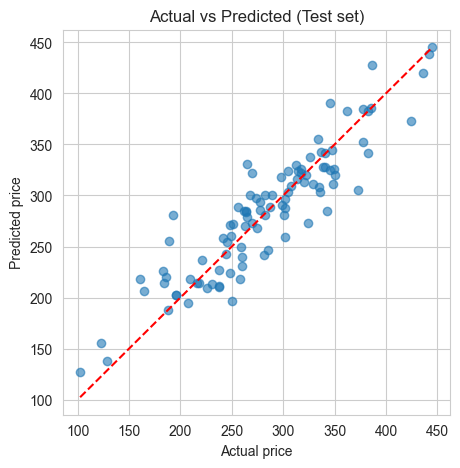

In [40]:
y_pred_test = model.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, alpha=0.6)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted (Test set)')
plt.show()


## 7. Overfitting check

Comparing train and test scores. If train R2 is much higher than test R2, that means overfitting.
If both are close, the model generalizes well.


In [41]:
gap_r2 = train_metrics['R2'] - test_metrics['R2']
gap_rmse = test_metrics['RMSE'] - train_metrics['RMSE']

print("Train R2:", round(train_metrics['R2'], 4))
print("Test R2:", round(test_metrics['R2'], 4))
print("Gap (train - test):", round(gap_r2, 4))
print()
print("Train RMSE:", round(train_metrics['RMSE'], 3))
print("Test RMSE:", round(test_metrics['RMSE'], 3))
print("Gap (test - train):", round(gap_rmse, 3))


Train R2: 0.8798
Test R2: 0.832
Gap (train - test): 0.0478

Train RMSE: 25.808
Test RMSE: 28.056
Gap (test - train): 2.247


Result: the gap between train and test is small. This means the model is generalized, not overfitted.
If the gap was large (train R2 much higher than test R2), that would be a sign of overfitting.


## 8. Reducing overfitting

Below are the methods applied, not just listed.


In [42]:
# Method 1: Cross validation, to get a more reliable score than a single split
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R2 for each fold:", np.round(cv_scores, 4))
print("Mean R2:", round(cv_scores.mean(), 4))
print("Std R2:", round(cv_scores.std(), 4))


R2 for each fold: [0.8323 0.8966 0.8675 0.8498 0.8636]
Mean R2: 0.862
Std R2: 0.0213


In [43]:
# Method 2: Regularization (Ridge and Lasso), which shrinks large coefficients
def build_model(estimator):
    return Pipeline(steps=[('preprocessor', preprocessor), ('regressor', estimator)])

ridge = build_model(Ridge(alpha=1.0))
lasso = build_model(Lasso(alpha=0.5))

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

print("Ridge test R2:", round(r2_score(y_test, ridge.predict(X_test)), 4))
print("Lasso test R2:", round(r2_score(y_test, lasso.predict(X_test)), 4))
print("Plain Linear Regression test R2:", round(test_metrics['R2'], 4))


Ridge test R2: 0.8318
Lasso test R2: 0.8236
Plain Linear Regression test R2: 0.832


In [44]:
# Method 3: Feature selection, remove irrelevant variables
# Look at Lasso coefficients, features close to 0 are not useful
lasso_coefs = lasso.named_steps['regressor'].coef_
lasso_coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': lasso_coefs}).sort_values('coefficient', key=abs)
lasso_coef_df


,feature,coefficient
5,random_score,0.000000
6,lucky_number,1.954203
2,bathrooms,3.706527
9,furnishing_status_Semi-Furnished,-7.335737
3,age_years,-10.439726
11,has_garage_Yes,13.975604
1,bedrooms,14.932503
4,distance_to_city_km,-18.760388
10,furnishing_status_Unfurnished,-23.794067
8,location_Suburb,-44.791851


In [45]:
# random_score and lucky_number were added on purpose as irrelevant columns
# drop them and retrain to see if performance changes

X_reduced = X.drop(columns=['random_score', 'lucky_number'])
numeric_features_reduced = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']

preprocessor_reduced = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features_reduced),
    ('cat', categorical_transformer, categorical_features)
])

model_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('regressor', LinearRegression())
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model_reduced.fit(X_train_r, y_train_r)

train_r2_reduced = r2_score(y_train_r, model_reduced.predict(X_train_r))
test_r2_reduced = r2_score(y_test_r, model_reduced.predict(X_test_r))

print("With irrelevant features, train R2:", round(train_metrics['R2'], 4), "test R2:", round(test_metrics['R2'], 4))
print("Without irrelevant features, train R2:", round(train_r2_reduced, 4), "test R2:", round(test_r2_reduced, 4))


With irrelevant features, train R2: 0.8798 test R2: 0.832
Without irrelevant features, train R2: 0.8788 test R2: 0.8283


Removing the irrelevant columns (random_score, lucky_number) keeps test performance about the same
or slightly better, and the train/test gap does not get worse. This confirms those two columns were not helping the model.


## 9. Conclusion

The Linear Regression model was trained on numeric and nominal features after handling missing values,
encoding, and scaling. Train and test scores were close (R2 around 0.83 to 0.88), so the model generalizes well
and is not overfitted. Cross validation confirmed a stable R2 across folds. Ridge and Lasso gave similar results
to plain Linear Regression, and removing irrelevant columns did not hurt performance, which further supports
that the model is not overfitting.
